In [10]:
target_cols = 'K_E'

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

input_folder=f'C:/Users/1/projects/zadachi/1 задача/{target_cols} determ'
output_file=f'{target_cols} determ.csv'
columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

In [12]:
def merge_txt_files_to_dataset():
    all_data = []

    for filename in os.listdir(input_folder):
        if filename.endswith('.txt'):
            filepath = os.path.join(input_folder, filename)
            df = pd.read_csv(filepath, sep='\s+', header=None, names=columns)

            all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df.to_csv(output_file, index=False)
    print(f"Датасет сохранен в {output_file} (строк: {len(combined_df)})")

# Пример использования

merge_txt_files_to_dataset()

Датасет сохранен в K_E determ.csv (строк: 100100)


In [13]:
df = pd.read_csv(output_file)
df = df[:99900]
df[:5]

,K_Nu,K_E,K_Rho,K_incl,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,1,0.5,1,1,0.1,10.000000,5.331410e-13,5.331447e-13,0.25,5.000000e+10,2700,3333.333333,1924.500897,2502.294446
1,1,0.5,1,1,0.2,5.000000,5.334885e-13,5.331474e-13,0.25,5.000000e+10,2700,3333.333333,1924.500897,2502.294446
2,1,0.5,1,1,0.3,3.333333,5.367156e-13,5.363296e-13,0.25,5.000000e+10,2700,3333.333333,1924.500897,2502.294446
3,1,0.5,1,1,0.4,2.500000,5.324516e-13,5.329968e-13,0.25,5.000000e+10,2700,3333.333333,1924.500897,2502.294446
4,1,0.5,1,1,0.5,2.000000,5.332178e-13,5.322721e-13,0.25,5.000000e+10,2700,3333.333333,1924.500897,2502.294446


In [14]:
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]
X

,A2/A2_s,F
0,0.999993,0.1
1,1.000640,0.2
2,1.000720,0.3
3,0.998977,0.4
4,1.001777,0.5
...,...,...
99895,1.008956,9.6
99896,1.009196,9.7
99897,1.009423,9.8
99898,1.009638,9.9


In [15]:
pearson_corr = df[['A2/A2_s', 'F', target_cols]].corr(method='pearson')
print("\nКорреляция Пирсона:")
print(pearson_corr.round(6))


Корреляция Пирсона:
          A2/A2_s         F       K_E
A2/A2_s  1.000000 -0.129402  0.124467
F       -0.129402  1.000000  0.000000
K_E      0.124467  0.000000  1.000000


In [16]:
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [18]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
    Dropout(0.2),  # Добавляем Dropout для регуляризации
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2),
    Dense(1, name='output_layer')
])

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Ранняя остановка для предотвращения переобучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1251 - mae: 0.2686 - val_loss: 0.0605 - val_mae: 0.1737
Epoch 2/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0699 - mae: 0.1945 - val_loss: 0.0479 - val_mae: 0.1384
Epoch 3/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0592 - mae: 0.1748 - val_loss: 0.0434 - val_mae: 0.1317
Epoch 4/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0533 - mae: 0.1631 - val_loss: 0.0421 - val_mae: 0.1267
Epoch 5/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0504 - mae: 0.1562 - val_loss: 0.0398 - val_mae: 0.1218
Epoch 6/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.0483 - mae: 0.1505 - val_loss: 0.0383 - val_mae: 0.1164
Epoch 7/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.0465 - mae: 0.1460 - val_loss: 0.0366 - val_mae: 0.1142
Epoch 8/100
1998/1998 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 0.0455 - mae: 0.1426 - val_loss: 0.0366 - val_mae: 0.1128
Epoch 9/100
1998/1998 ━━━━━━

In [22]:
y_pred= np.array(model.predict(X_test)).flatten()
y_test = np.array(y_test)
y_test, y_pred

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


(array([1.64  , 0.6815, 1.1375, ..., 1.802 , 1.625 , 0.929 ]),
 array([1.3999555, 0.9607618, 1.1313808, ..., 1.6776375, 1.6156051,
        1.2382848], dtype=float32))

In [23]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
relative_errors = np.abs((y_test - y_pred) / y_test) * 100
mean_relative_error = np.mean(relative_errors)
std_relative_error = np.std(relative_errors)

In [24]:

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Absolute Per Error (MAPE): {mape:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")


РЕЗУЛЬТАТЫ МОДЕЛИ
Mean Squared Error (MSE): 0.025410
Mean Absolute Error (MAE): 0.085473
Mean Absolute Per Error (MAPE): 0.081640
Root Mean Squared Error (RMSE): 0.159406
R² Score: 0.864474


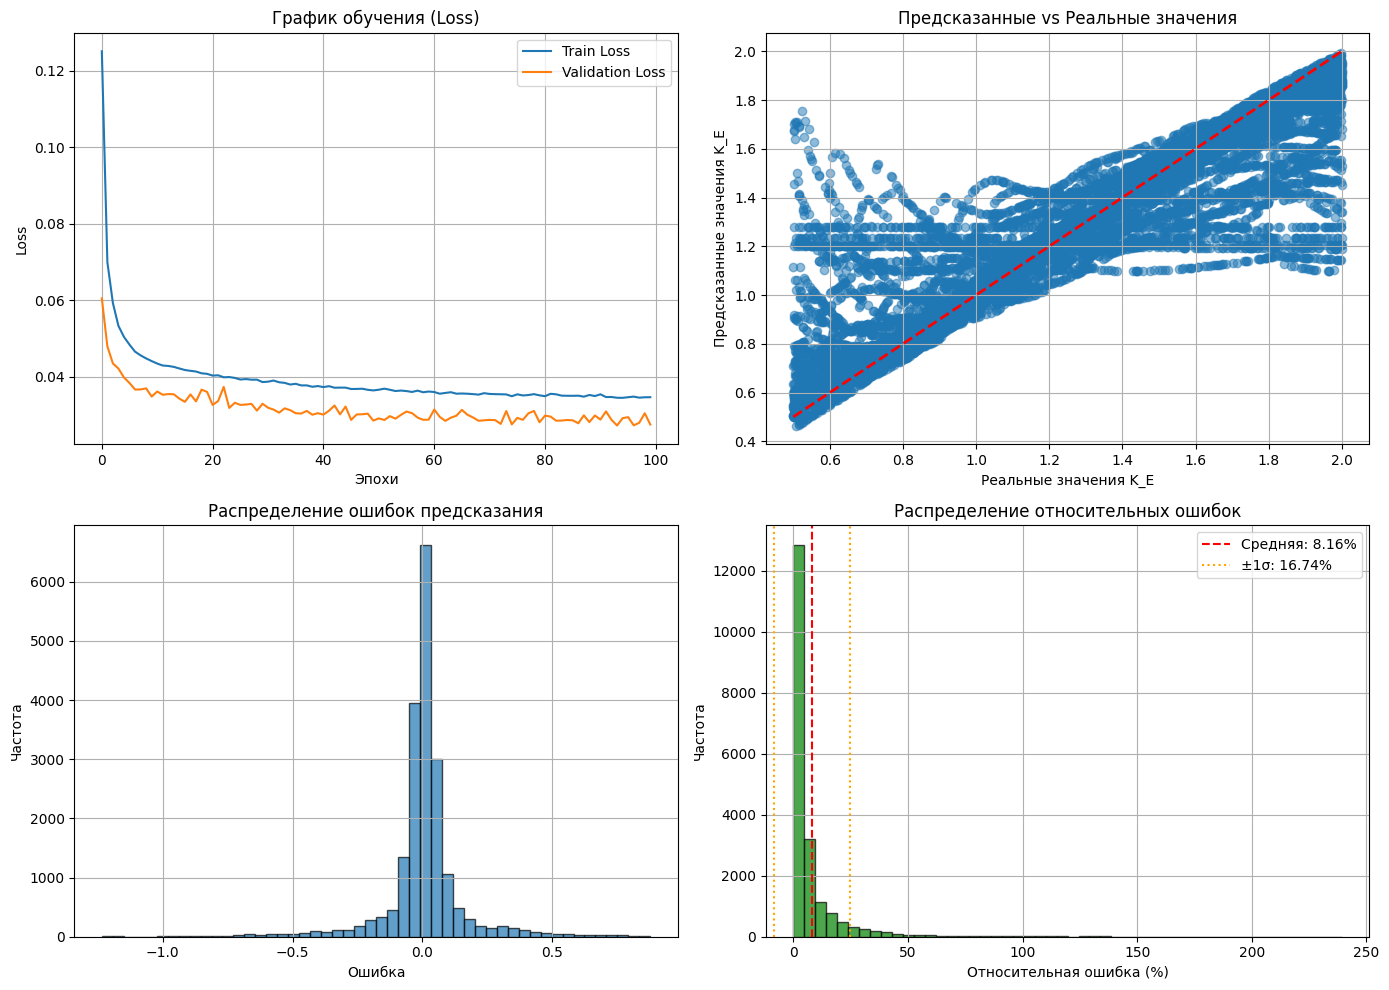


ДЕТАЛЬНАЯ СТАТИСТИКА
Минимальная относительная ошибка: 0.00%
Максимальная относительная ошибка: 239.28%
Медианная относительная ошибка: 3.01%
25-й перцентиль: 1.38%
75-й перцентиль: 7.16%

ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)
 Реальный K_E  Предсказанный K_E  Абсолютная ошибка  Относительная ошибка (%)
       1.6400           1.399956           0.240044                 14.636859
       0.6815           0.960762           0.279262                 40.977518
       1.1375           1.131381           0.006119                  0.537952
       1.9940           1.888495           0.105505                  5.291125
       0.9770           0.998167           0.021167                  2.166540
       1.9430           1.823513           0.119487                  6.149612
       1.3715           1.188344           0.183156                 13.354447
       0.6680           1.156902           0.488902                 73.188880
       1.7465           1.712926           0.033574      

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. График обучения
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('График обучения (Loss)')
axes[0, 0].set_xlabel('Эпохи')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Сравнение предсказанных и реальных значений
axes[0, 1].scatter(y_test, y_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Предсказанные vs Реальные значения')
axes[0, 1].set_xlabel(f'Реальные значения {target_cols}')
axes[0, 1].set_ylabel(f'Предсказанные значения {target_cols}')
axes[0, 1].grid(True)

# 3. Распределение ошибок
errors = y_test.flatten() - y_pred.flatten()
axes[1, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение ошибок предсказания')
axes[1, 0].set_xlabel('Ошибка')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True)

#
# 4. Распределение относительных ошибок
axes[1, 1].hist(relative_errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(mean_relative_error, color='red', linestyle='--', 
                   label=f'Средняя: {mean_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error + std_relative_error, color='orange', 
                   linestyle=':', label=f'±1σ: {std_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error - std_relative_error, color='orange', linestyle=':')
axes[1, 1].set_title('Распределение относительных ошибок')
axes[1, 1].set_xlabel('Относительная ошибка (%)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(f"Минимальная относительная ошибка: {relative_errors.min():.2f}%")
print(f"Максимальная относительная ошибка: {relative_errors.max():.2f}%")
print(f"Медианная относительная ошибка: {np.median(relative_errors):.2f}%")
print(f"25-й перцентиль: {np.percentile(relative_errors, 25):.2f}%")
print(f"75-й перцентиль: {np.percentile(relative_errors, 75):.2f}%")


# Примеры предсказаний
print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)")
print("="*50)
examples = pd.DataFrame({
    f'Реальный {target_cols}': y_test.flatten()[:10],
    f'Предсказанный {target_cols}': y_pred.flatten()[:10],
    'Абсолютная ошибка': np.abs(y_test.flatten()[:10] - y_pred.flatten()[:10]),
    'Относительная ошибка (%)': relative_errors.flatten()[:10]
})
print(examples.to_string(index=False))

# Сохранение модели
model.save(f'{target_cols}_prediction_model.h5')
print("\nМодель сохранена")

In [26]:
accuracy_5_percent = np.mean(relative_errors < 5) * 100
print(f"Процент предсказаний с ошибкой < 5%: {accuracy_5_percent:.2f}%")

Процент предсказаний с ошибкой < 5%: 65.49%
